In [37]:

import os
import numpy as np
import pandas as pd
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import cv2
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
import seaborn as sns
from vq_vae import VQVAE
import torch
import unittest
from torchinfo import summary
import sys
import os

SEED = 46  

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"✅ Global seed set to {SEED}")


✅ Global seed set to 46


In [38]:

DATASET_PATH = r"C:\Users\pc\Downloads\weed_dataset\dataset"  
CHECKPOINT_DIR = r"checkpoints"

class_folders = sorted([f for f in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, f))])
print(f"Found {len(class_folders)} classes: {class_folders}")

class_to_idx = {class_name: idx for idx, class_name in enumerate(class_folders)}
idx_to_class = {idx: class_name for class_name, idx in class_to_idx.items()}
print(f"Class mapping: {class_to_idx}")

Found 4 classes: ['broadleaf', 'grass', 'soil', 'soybean']
Class mapping: {'broadleaf': 0, 'grass': 1, 'soil': 2, 'soybean': 3}


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.0001
RANDOM_STATE = 101
TRAIN_COUNT = 7000
TEST_COUNT = 3000
TRAIN_TEST_SPLIT_RATIO = 0.8
NUM_EMBEDDINGS = 512
EMBEDDINGS_DIM = 64
BETA = 0.25
LR_SCHEDULER_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
IN_CHANNELS = 3
EARLY_STOPPING_PATIENCE = 5

In [40]:

def split_dataset(dataset_path, class_folders, train_ratio=0.8, random_state=RANDOM_STATE):
    
    train_data = []
    val_data = []
    
    for class_name in class_folders:
        class_path = os.path.join(dataset_path, class_name)
        class_idx = class_to_idx[class_name]
        
        image_files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.JPG', '*.JPEG', '*.PNG', '*.tif']:
            image_files.extend(glob(os.path.join(class_path, ext)))
        
        print(f"Class '{class_name}': {len(image_files)} images")
        
        train_files, val_files = train_test_split(
            image_files, 
            train_size=train_ratio, 
            random_state=random_state,
            shuffle=True
        )
        
        train_data.extend([(f, class_idx) for f in train_files])
        val_data.extend([(f, class_idx) for f in val_files])
    
    print(f"\nTrain set: {len(train_data)} images")
    print(f"Validation set: {len(val_data)} images")
    
    return train_data, val_data


train_data, val_data = split_dataset(DATASET_PATH, class_folders, train_ratio=0.8)

Class 'broadleaf': 1191 images
Class 'grass': 3520 images
Class 'soil': 3249 images
Class 'soybean': 7376 images

Train set: 12267 images
Validation set: 3069 images


In [41]:

class ImageDataset(Dataset):
    def __init__(self, data_list, img_size=IMG_SIZE, augment=False):
        
        self.data_list = data_list
        self.img_size = img_size
        self.augment = augment
    
    def __len__(self):
        return len(self.data_list)
    
    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        img = cv2.resize(img, (self.img_size, self.img_size))
        
        if self.augment:
            if random.random() > 0.5:
                img = cv2.flip(img, 1)
            
            if random.random() > 0.5:
                factor = random.uniform(0.8, 1.2)
                img = np.clip(img * factor, 0, 255).astype(np.uint8)
        
        img = img.astype(np.float32) / 255.0
        
        img = torch.from_numpy(img).permute(2, 0, 1)
        
        return img, label


train_dataset = ImageDataset(train_data, img_size=IMG_SIZE, augment=True)
val_dataset = ImageDataset(val_data, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 384
Validation batches: 96


In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from datetime import datetime


# Initialize model
model = VQVAE(
    in_channels=IN_CHANNELS,
    num_embeddings=NUM_EMBEDDINGS,
    embedding_dim=EMBEDDINGS_DIM,
    img_size=IMG_SIZE,
    beta=BETA
).to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=LR_SCHEDULER_FACTOR, 
    patience=LR_SCHEDULER_PATIENCE, 
    verbose=True
)

# Create checkpoint directory
checkpoint_dir = CHECKPOINT_DIR
os.makedirs(checkpoint_dir, exist_ok=True)

# Best model path
best_model_path = os.path.join(checkpoint_dir, f"best_vqvae_{IMG_SIZE}.pth")

print(f"Model initialized")
print(f"Device: {device}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Best model will be saved to: {best_model_path}")


Model initialized
Device: cuda
Learning Rate: 0.0001
Batch Size: 32
Epochs: 15
Image Size: 256x256
Best model will be saved to: checkpoints\best_vqvae_256.pth


d:\D-Documents\University\sem7_venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


# Light Weight D + SnE Conv Quantized Latent Space Classifier

In [43]:

class SEBlock(nn.Module):
    """Squeeze-and-Excitation Block"""
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b, c, _, _ = x.size()
        # Squeeze: global average pooling
        y = self.squeeze(x).view(b, c)
        # Excitation: channel-wise attention weights
        y = self.excitation(y).view(b, c, 1, 1)
        # Scale original features
        return x * y.expand_as(x)


class DepthwiseSeparableConv(nn.Module):
    """Depthwise Separable Convolution block with SE"""
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1, stride=1, use_se=True):
        super(DepthwiseSeparableConv, self).__init__()
        
        # Depthwise convolution
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, 
            kernel_size=kernel_size, 
            padding=padding, 
            stride=stride,
            groups=in_channels,
            bias=False
        )
        
        # Pointwise convolution (1x1)
        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1,
            bias=False
        )
        
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        # Squeeze-and-Excitation
        self.use_se = use_se
        if use_se:
            self.se = SEBlock(out_channels, reduction=16)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        x = self.bn(x)
        x = self.relu(x)
        
        if self.use_se:
            x = self.se(x)
        
        return x


class LatentClassifier_D_SnE(nn.Module):
    """
    Classifier with Depthwise Separable Convolutions + SE blocks
    """
    def __init__(self, vqvae_model, latent_dim=64, num_classes=len(class_folders), freeze_vqvae=True):
        super(LatentClassifier_D_SnE, self).__init__()
        
        # Store the entire VQVAE model (encoder + vq_layer)
        self.vqvae = vqvae_model
        
        # Freeze VQVAE weights if specified
        if freeze_vqvae:
            for param in self.vqvae.parameters():
                param.requires_grad = False
        
        # CNN layers with Depthwise Separable Convolutions + SE
        self.cnn = nn.Sequential(
            # First block: 64 -> 128
            DepthwiseSeparableConv(latent_dim, 128, kernel_size=3, padding=1, use_se=True),
            nn.MaxPool2d(2),
            
            # Second block: 128 -> 256
            DepthwiseSeparableConv(128, 256, kernel_size=3, padding=1, use_se=True),
            nn.MaxPool2d(2),
            
            # Third block: 256 -> 512
            DepthwiseSeparableConv(256, 512, kernel_size=3, padding=1, use_se=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # MLP classifier
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        # Extract encoder features and then quantize them
        with torch.no_grad():
            # Get encoder output
            encoded = self.vqvae.encoder(x)
            # Pass through VQ layer to get quantized latents
            quantized_latents, vq_loss = self.vqvae.vq_layer(encoded)
        
        # Process quantized latents through CNN
        features = self.cnn(quantized_latents)
        
        # Classify through MLP
        output = self.mlp(features)
        
        return output


# Load pre-trained VQVAE weights
print("Loading pre-trained VQVAE model...")
best_model_path = os.path.join(checkpoint_dir, f"best_vqvae_{IMG_SIZE}.pth")
vqvae_model = VQVAE(
    in_channels=IN_CHANNELS,
    num_embeddings=NUM_EMBEDDINGS,
    embedding_dim=EMBEDDINGS_DIM,
    img_size=IMG_SIZE,
    beta=BETA
).to(device)

# Load the saved checkpoint
checkpoint = torch.load(best_model_path, map_location=device)
vqvae_model.load_state_dict(checkpoint['model_state_dict'])
vqvae_model.eval()
print(f"✅ Loaded weights from: {best_model_path}")
print(f"✅ Using VQVAE encoder + VQ quantizer for feature extraction")
print(f"✅ Using Depthwise Separable Convolutions + SE blocks")

# Create classifier
classifier = LatentClassifier_D_SnE(
    vqvae_model=vqvae_model,
    latent_dim=EMBEDDINGS_DIM,
    num_classes=len(class_folders),
    freeze_vqvae=True
).to(device)

# Print model summary
print("\n" + "="*60)
print("CLASSIFIER ARCHITECTURE (DepthwiseSep + SE)")
print("="*60)
total_params = sum(p.numel() for p in classifier.parameters())
trainable_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

# Test forward pass
with torch.no_grad():
    test_input = torch.randn(1, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(device)
    test_output = classifier(test_input)
    print(f"\n✅ Forward pass test successful!")
    print(f"Output shape: {test_output.shape}")

Loading pre-trained VQVAE model...
✅ Loaded weights from: checkpoints\best_vqvae_256.pth
✅ Using VQVAE encoder + VQ quantizer for feature extraction
✅ Using Depthwise Separable Convolutions + SE blocks

CLASSIFIER ARCHITECTURE (DepthwiseSep + SE)
Total parameters: 10,098,311
Trainable parameters: 385,604
Frozen parameters: 9,712,707

✅ Forward pass test successful!
Output shape: torch.Size([1, 4])



DETAILED LAYER-WISE PARAMETERS

🔷 CNN LAYERS:
------------------------------------------------------------
Layer 0 (DepthwiseSeparableConv): 11,072 parameters
  ├─ Depthwise: 576 params
  │  └─ Weight shape: torch.Size([64, 1, 3, 3])
  ├─ Pointwise: 8,192 params
  │  └─ Weight shape: torch.Size([128, 64, 1, 1])
  └─ BatchNorm: 256 params
Layer 2 (DepthwiseSeparableConv): 42,624 parameters
  ├─ Depthwise: 1,152 params
  │  └─ Weight shape: torch.Size([128, 1, 3, 3])
  ├─ Pointwise: 32,768 params
  │  └─ Weight shape: torch.Size([256, 128, 1, 1])
  └─ BatchNorm: 512 params
Layer 4 (DepthwiseSeparableConv): 167,168 parameters
  ├─ Depthwise: 2,304 params
  │  └─ Weight shape: torch.Size([256, 1, 3, 3])
  ├─ Pointwise: 131,072 params
  │  └─ Weight shape: torch.Size([512, 256, 1, 1])
  └─ BatchNorm: 1,024 params

Total CNN parameters: 220,864

🔶 MLP LAYERS:
------------------------------------------------------------
Layer 1 (Linear): 131,328 parameters
  └─ Weight shape: torch.Size([256,

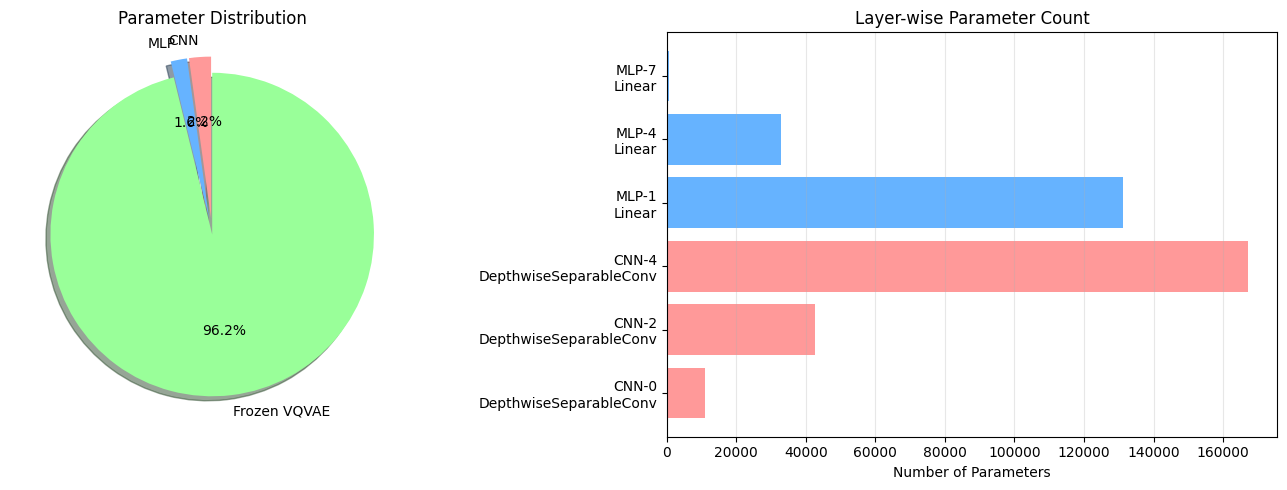

In [44]:

# Detailed parameter breakdown
print("\n" + "="*60)
print("DETAILED LAYER-WISE PARAMETERS")
print("="*60)

# CNN Layers
print("\n🔷 CNN LAYERS:")
print("-" * 60)
cnn_total = 0
for i, layer in enumerate(classifier.cnn):
    # Check if it's a custom module (like DepthwiseSeparableConv) or standard layer
    layer_params = sum(p.numel() for p in layer.parameters())
    
    if layer_params > 0:  # Only show layers with parameters
        cnn_total += layer_params
        print(f"Layer {i} ({layer.__class__.__name__}): {layer_params:,} parameters")
        
        # For custom modules, show sub-layers
        if isinstance(layer, DepthwiseSeparableConv):
            print(f"  ├─ Depthwise: {sum(p.numel() for p in layer.depthwise.parameters()):,} params")
            print(f"  │  └─ Weight shape: {layer.depthwise.weight.shape}")
            print(f"  ├─ Pointwise: {sum(p.numel() for p in layer.pointwise.parameters()):,} params")
            print(f"  │  └─ Weight shape: {layer.pointwise.weight.shape}")
            print(f"  └─ BatchNorm: {sum(p.numel() for p in layer.bn.parameters()):,} params")
        # For standard layers
        elif hasattr(layer, 'weight'):
            print(f"  └─ Weight shape: {layer.weight.shape}")
            if hasattr(layer, 'bias') and layer.bias is not None:
                print(f"  └─ Bias shape: {layer.bias.shape}")

print(f"\nTotal CNN parameters: {cnn_total:,}")

# MLP Layers
print("\n🔶 MLP LAYERS:")
print("-" * 60)
mlp_total = 0
for i, layer in enumerate(classifier.mlp):
    if hasattr(layer, 'weight'):
        params = sum(p.numel() for p in layer.parameters())
        mlp_total += params
        print(f"Layer {i} ({layer.__class__.__name__}): {params:,} parameters")
        if hasattr(layer, 'weight'):
            print(f"  └─ Weight shape: {layer.weight.shape}")
        if hasattr(layer, 'bias') and layer.bias is not None:
            print(f"  └─ Bias shape: {layer.bias.shape}")

print(f"\nTotal MLP parameters: {mlp_total:,}")

# Summary
print("\n" + "="*60)
print("TRAINABLE PARAMETERS SUMMARY")
print("="*60)
print(f"CNN layers: {cnn_total:,}")
print(f"MLP layers: {mlp_total:,}")
print(f"Total trainable: {cnn_total + mlp_total:,}")
print(f"Frozen VQVAE: {total_params - trainable_params:,}")
print(f"Grand Total: {total_params:,}")

# Breakdown comparison
print(f"\n📊 ARCHITECTURE BREAKDOWN:")
print(f"  • Depthwise Separable CNN: {cnn_total:,} ({(cnn_total/trainable_params)*100:.1f}%)")
print(f"  • MLP Classifier: {mlp_total:,} ({(mlp_total/trainable_params)*100:.1f}%)")
print(f"  • Frozen VQVAE: {total_params - trainable_params:,}")
print("="*60)

# Visualize parameter distribution
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart for trainable vs frozen
labels = ['CNN', 'MLP', 'Frozen VQVAE']
sizes = [cnn_total, mlp_total, total_params - trainable_params]
colors = ['#ff9999', '#66b3ff', '#99ff99']
explode = (0.1, 0.1, 0)

ax1.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.set_title('Parameter Distribution')

# Bar chart for layer-wise parameters
layer_names = []
layer_params = []

# Collect CNN layer parameters
for i, layer in enumerate(classifier.cnn):
    params = sum(p.numel() for p in layer.parameters())
    if params > 0:
        layer_names.append(f'CNN-{i}\n{layer.__class__.__name__}')
        layer_params.append(params)

# Collect MLP layer parameters
for i, layer in enumerate(classifier.mlp):
    if hasattr(layer, 'weight'):
        layer_names.append(f'MLP-{i}\n{layer.__class__.__name__}')
        layer_params.append(sum(p.numel() for p in layer.parameters()))

# Count CNN and MLP layers with parameters
cnn_layer_count = sum(1 for layer in classifier.cnn if sum(p.numel() for p in layer.parameters()) > 0)
mlp_layer_count = sum(1 for layer in classifier.mlp if hasattr(layer, 'weight'))

ax2.barh(layer_names, layer_params, 
         color=['#ff9999']*cnn_layer_count + ['#66b3ff']*mlp_layer_count)
ax2.set_xlabel('Number of Parameters')
ax2.set_title('Layer-wise Parameter Count')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(checkpoint_dir, 'classifier_parameters.png'), dpi=300, bbox_inches='tight')
plt.show()

# Model Initialization

In [45]:

num_classes = len(class_folders)
print("Loading pre-trained VQVAE model...")
best_model_path = os.path.join(checkpoint_dir, f"best_vqvae_{IMG_SIZE}.pth")
vqvae_model = VQVAE(
    in_channels=IN_CHANNELS,
    num_embeddings=NUM_EMBEDDINGS,
    embedding_dim=EMBEDDINGS_DIM,
    img_size=IMG_SIZE,
    beta=BETA
).to(device)

# Load the saved checkpoint
checkpoint = torch.load(best_model_path, map_location=device)
vqvae_model.load_state_dict(checkpoint['model_state_dict'])
vqvae_model.eval()
print(f"Loaded weights from: {best_model_path}")
print(f"Using VQVAE encoder + VQ quantizer for feature extraction")
print(f"Using Depthwise Separable Convolutions + SE blocks")

# Create model
model = LatentClassifier_D_SnE(
    vqvae_model=vqvae_model,
    latent_dim=EMBEDDINGS_DIM,
    num_classes=num_classes,
    freeze_vqvae=True
).to(device)

# Print model summary
print("\n" + "="*60)
print("CLASSIFIER ARCHITECTURE (DepthwiseSep + SE)")
print("="*60)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

# Test forward pass
with torch.no_grad():
    test_input = torch.randn(1, IN_CHANNELS, IMG_SIZE, IMG_SIZE).to(device)
    test_output = model(test_input)
    print(f"\nForward pass test successful!")
    print(f"Output shape: {test_output.shape}")


model_name = f"{model.__class__.__name__}"
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',                    # Minimize validation loss
    factor=LR_SCHEDULER_FACTOR,    # Multiply LR by this factor (0.5)
    patience=LR_SCHEDULER_PATIENCE, # Wait 2 epochs before reducing
    verbose=True,                   # Print when LR changes
    min_lr=1e-7                    # Don't go below this LR
)

print(f"\nModel initialized with {num_classes} classes")

Loading pre-trained VQVAE model...
Loaded weights from: checkpoints\best_vqvae_256.pth
Using VQVAE encoder + VQ quantizer for feature extraction
Using Depthwise Separable Convolutions + SE blocks

CLASSIFIER ARCHITECTURE (DepthwiseSep + SE)
Total parameters: 10,098,311
Trainable parameters: 385,604
Frozen parameters: 9,712,707

Forward pass test successful!
Output shape: torch.Size([1, 4])

Model initialized with 4 classes


In [46]:

# * Training and Validation Functions
def calculate_metrics(y_true, y_pred, num_classes):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    return accuracy, precision, recall, f1


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc="Training")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # * Zero gradients
        optimizer.zero_grad()
        
        # * Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # * Backward pass
        loss.backward()
        optimizer.step()
        
        # * Statistics
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(loader)
    accuracy, precision, recall, f1 = calculate_metrics(all_labels, all_preds, len(class_folders))
    
    return epoch_loss, accuracy, precision, recall, f1


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation")
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            # * Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # * Statistics
            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(loader)
    accuracy, precision, recall, f1 = calculate_metrics(all_labels, all_preds, len(class_folders))
    
    return epoch_loss, accuracy, precision, recall, f1, all_labels, all_preds, all_probs


In [47]:

# * Training Loop with LR Scheduler
history = {
    'train_loss': [], 'train_acc': [], 'train_precision': [], 'train_recall': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_precision': [], 'val_recall': [], 'val_f1': [],
    'learning_rates': []  # Track learning rate changes
}

best_val_acc = 0.0
best_val_loss = float('inf')  # Track best validation loss for early stopping
best_classifier_model_path = CHECKPOINT_DIR + f'/my_best_model_{model_name}.pth'
no_improve_epochs = 0  # Counter for early stopping

print(f"\n{'='*60}")
print(f"Starting Training on {device}")
print(f"{'='*60}\n")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 60)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Current Learning Rate: {current_lr:.2e}")
    
    # * Train
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # * Validate
    val_loss, val_acc, val_prec, val_rec, val_f1, val_labels, val_preds, val_probs = validate_epoch(
        model, val_loader, criterion, device
    )
    
    # Step the scheduler based on validation loss
    scheduler.step(val_loss)
    
    # * Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_precision'].append(train_prec)
    history['train_recall'].append(train_rec)
    history['train_f1'].append(train_f1)
    
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_precision'].append(val_prec)
    history['val_recall'].append(val_rec)
    history['val_f1'].append(val_f1)
    history['learning_rates'].append(current_lr)  # Track LR
    
    # * Print epoch summary
    print(f"\nTrain Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Prec: {train_prec:.4f} | Rec: {train_rec:.4f} | F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}")
    
    # * Save best model (based on validation accuracy)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
        }, best_classifier_model_path)
        print(f"Best model saved with validation accuracy: {val_acc:.4f}")
    
    # Early stopping based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        print(f"\nNo improvement for {no_improve_epochs} epoch(s)")
        
        if no_improve_epochs >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered after {epoch + 1} epochs")
            print(f"Best validation loss: {best_val_loss:.4f}")
            break

print(f"\n{'='*60}")
print(f"Training Complete!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Final Learning Rate: {optimizer.param_groups[0]['lr']:.2e}")
print(f"{'='*60}\n")


Starting Training on cuda


Epoch 1/15
------------------------------------------------------------
Current Learning Rate: 1.00e-04


Validation: 100%|██████████| 96/96 [00:09<00:00,  9.62it/s, loss=0.0623] 



Train Loss: 0.6234 | Acc: 0.7720 | Prec: 0.6718 | Rec: 0.5972 | F1: 0.5815
Val   Loss: 0.3504 | Acc: 0.8579 | Prec: 0.6433 | Rec: 0.6903 | F1: 0.6653
Best model saved with validation accuracy: 0.8579

Epoch 2/15
------------------------------------------------------------
Current Learning Rate: 1.00e-04


Validation: 100%|██████████| 96/96 [00:09<00:00,  9.61it/s, loss=0.0035]  



Train Loss: 0.3351 | Acc: 0.8684 | Prec: 0.7693 | Rec: 0.7080 | F1: 0.6862
Val   Loss: 0.3875 | Acc: 0.8501 | Prec: 0.8495 | Rec: 0.7171 | F1: 0.7470

No improvement for 1 epoch(s)

Epoch 3/15
------------------------------------------------------------
Current Learning Rate: 1.00e-04


...


Train Loss: 0.0657 | Acc: 0.9782 | Prec: 0.9670 | Rec: 0.9652 | F1: 0.9661
Val   Loss: 0.0482 | Acc: 0.9834 | Prec: 0.9773 | Rec: 0.9726 | F1: 0.9748
Best model saved with validation accuracy: 0.9834

Epoch 14/15
------------------------------------------------------------
Current Learning Rate: 1.00e-04


Validation: 100%|██████████| 96/96 [00:09<00:00,  9.66it/s, loss=0.00322] 



Train Loss: 0.0573 | Acc: 0.9813 | Prec: 0.9730 | Rec: 0.9697 | F1: 0.9713
Val   Loss: 0.1159 | Acc: 0.9589 | Prec: 0.9203 | Rec: 0.9558 | F1: 0.9302

No improvement for 1 epoch(s)

Epoch 15/15
------------------------------------------------------------
Current Learning Rate: 1.00e-04


Validation: 100%|██████████| 96/96 [00:09<00:00,  9.69it/s, loss=0.0472]  


Train Loss: 0.0612 | Acc: 0.9804 | Prec: 0.9720 | Rec: 0.9689 | F1: 0.9704
Val   Loss: 0.0792 | Acc: 0.9700 | Prec: 0.9678 | Rec: 0.9520 | F1: 0.9586

No improvement for 2 epoch(s)

Training Complete!
Best Validation Accuracy: 0.9834
Best Validation Loss: 0.0482
Final Learning Rate: 1.00e-04



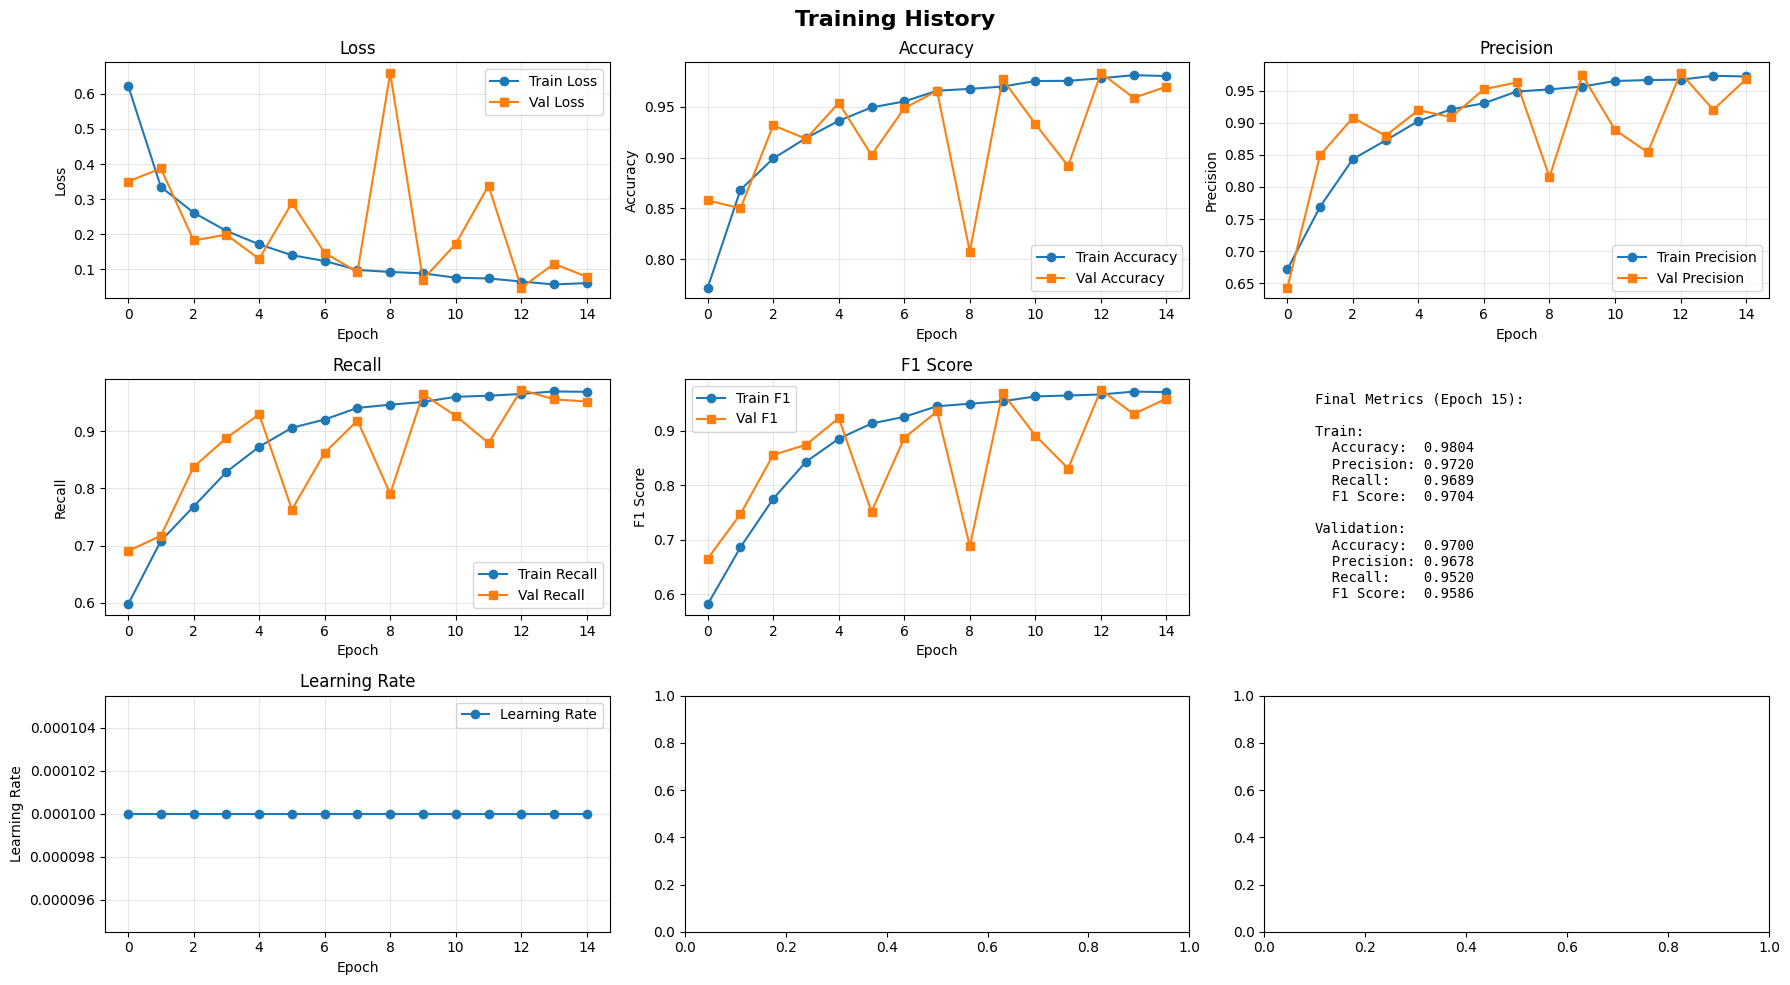

Training history plot saved as 'training_history_LatentClassifier_D_SnE.png'


In [48]:

# * Plot Training History (Metrics Graphs)
fig, axes = plt.subplots(3, 3, figsize=(18, 10))
fig.suptitle('Training History', fontsize=16, fontweight='bold')

# * Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# * Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', marker='s')
axes[0, 1].set_title('Accuracy')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# * Precision
axes[0, 2].plot(history['train_precision'], label='Train Precision', marker='o')
axes[0, 2].plot(history['val_precision'], label='Val Precision', marker='s')
axes[0, 2].set_title('Precision')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# * Recall
axes[1, 0].plot(history['train_recall'], label='Train Recall', marker='o')
axes[1, 0].plot(history['val_recall'], label='Val Recall', marker='s')
axes[1, 0].set_title('Recall')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# * F1 Score
axes[1, 1].plot(history['train_f1'], label='Train F1', marker='o')
axes[1, 1].plot(history['val_f1'], label='Val F1', marker='s')
axes[1, 1].set_title('F1 Score')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# * Summary table
summary_text = f"""
Final Metrics (Epoch {EPOCHS}):

Train:
  Accuracy:  {history['train_acc'][-1]:.4f}
  Precision: {history['train_precision'][-1]:.4f}
  Recall:    {history['train_recall'][-1]:.4f}
  F1 Score:  {history['train_f1'][-1]:.4f}

Validation:
  Accuracy:  {history['val_acc'][-1]:.4f}
  Precision: {history['val_precision'][-1]:.4f}
  Recall:    {history['val_recall'][-1]:.4f}
  F1 Score:  {history['val_f1'][-1]:.4f}
"""
axes[1, 2].text(0.1, 0.5, summary_text, fontsize=10, family='monospace',
                verticalalignment='center', transform=axes[1, 2].transAxes)
axes[1, 2].axis('off')

# * F1 Score
axes[2, 0].plot(history['learning_rates'], label='Learning Rate', marker='o')
axes[2, 0].set_title('Learning Rate')
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Learning Rate')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'training_history_{model_name}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Training history plot saved as 'training_history_{model_name}.png'")

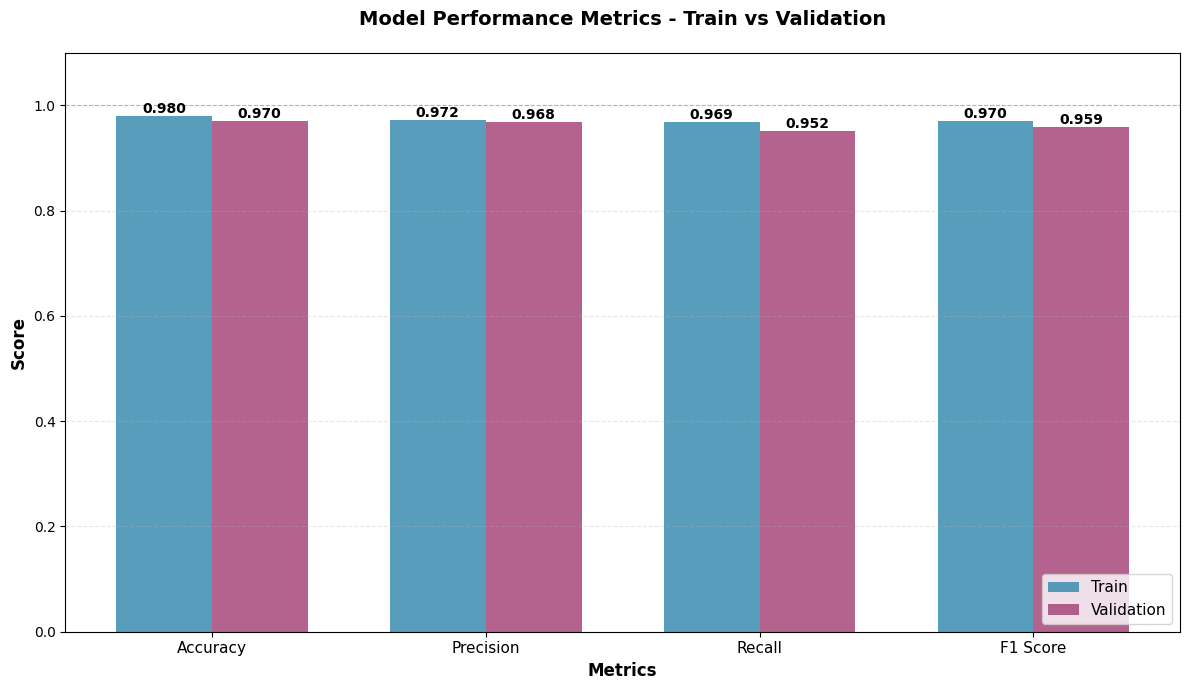

Metrics bar plot saved as 'metrics_barplot_LatentClassifier_D_SnE.png'

Final Metrics Summary:
Accuracy     - Train: 0.9804 | Val: 0.9700
Precision    - Train: 0.9720 | Val: 0.9678
Recall       - Train: 0.9689 | Val: 0.9520
F1 Score     - Train: 0.9704 | Val: 0.9586


In [49]:

# * Get final metrics from training and validation
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_values = [
    history['train_acc'][-1],
    history['train_precision'][-1],
    history['train_recall'][-1],
    history['train_f1'][-1]
]
val_values = [
    history['val_acc'][-1],
    history['val_precision'][-1],
    history['val_recall'][-1],
    history['val_f1'][-1]
]

# * Set up the bar plot
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, train_values, width, label='Train', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x + width/2, val_values, width, label='Validation', color='#A23B72', alpha=0.8)

# * Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)

# * Customize plot
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Metrics - Train vs Validation', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# * Add horizontal line at y=1.0 for reference
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(f'metrics_barplot_{model_name}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Metrics bar plot saved as 'metrics_barplot_{model_name}.png'")

# * Print the values
print("\n" + "="*60)
print("Final Metrics Summary:")
print("="*60)
for i, metric in enumerate(metrics):
    print(f"{metric:12s} - Train: {train_values[i]:.4f} | Val: {val_values[i]:.4f}")

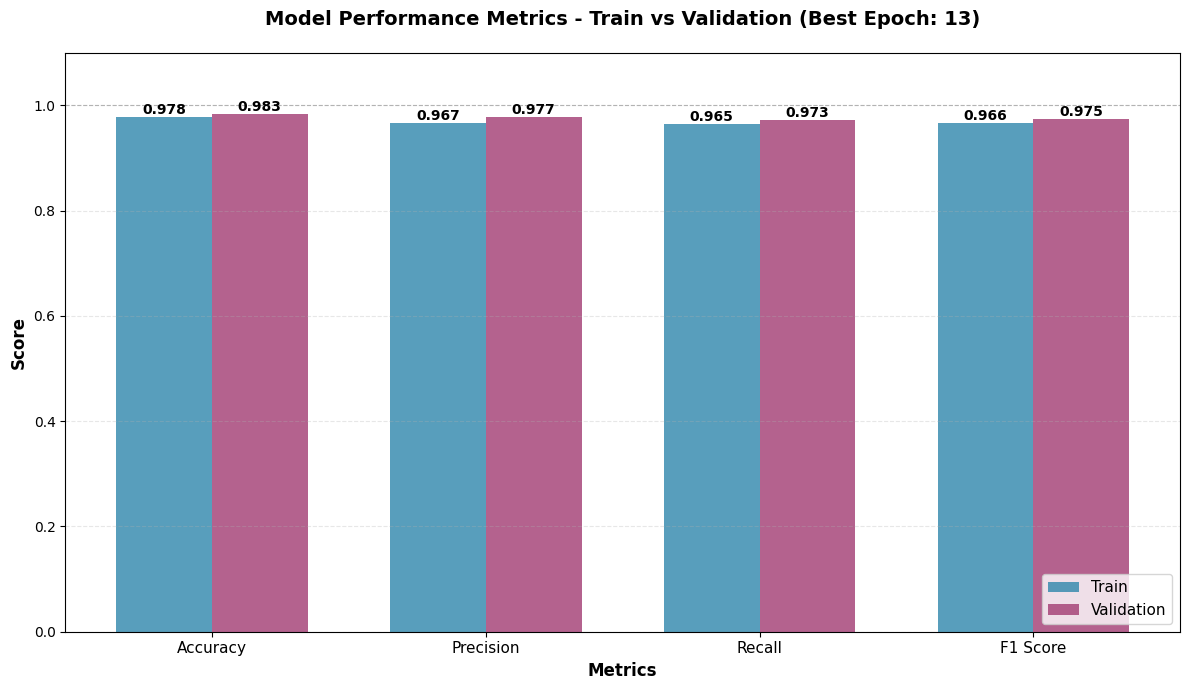

Metrics bar plot saved as 'metrics_barplot_LatentClassifier_D_SnE_best.png'

Best Model Metrics (Epoch 13):
Accuracy     - Train: 0.9782 | Val: 0.9834
Precision    - Train: 0.9670 | Val: 0.9773
Recall       - Train: 0.9652 | Val: 0.9726
F1 Score     - Train: 0.9661 | Val: 0.9748


In [50]:

# * Get metrics from the epoch with best validation accuracy
best_epoch_idx = np.argmax(history['val_acc'])
best_epoch_num = best_epoch_idx + 1

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_values = [
    history['train_acc'][best_epoch_idx],
    history['train_precision'][best_epoch_idx],
    history['train_recall'][best_epoch_idx],
    history['train_f1'][best_epoch_idx]
]
val_values = [
    history['val_acc'][best_epoch_idx],
    history['val_precision'][best_epoch_idx],
    history['val_recall'][best_epoch_idx],
    history['val_f1'][best_epoch_idx]
]

# * Set up the bar plot
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, train_values, width, label='Train', color='#2E86AB', alpha=0.8)
bars2 = ax.bar(x + width/2, val_values, width, label='Validation', color='#A23B72', alpha=0.8)

# * Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)

# * Customize plot
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Model Performance Metrics - Train vs Validation (Best Epoch: {best_epoch_num})', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# * Add horizontal line at y=1.0 for reference
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(f'metrics_barplot_{model_name}_best.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Metrics bar plot saved as 'metrics_barplot_{model_name}_best.png'")

# * Print the values
print("\n" + "="*60)
print(f"Best Model Metrics (Epoch {best_epoch_num}):")
print("="*60)
for i, metric in enumerate(metrics):
    print(f"{metric:12s} - Train: {train_values[i]:.4f} | Val: {val_values[i]:.4f}")

Validation: 100%|██████████| 96/96 [00:24<00:00,  3.97it/s, loss=0.0327]  


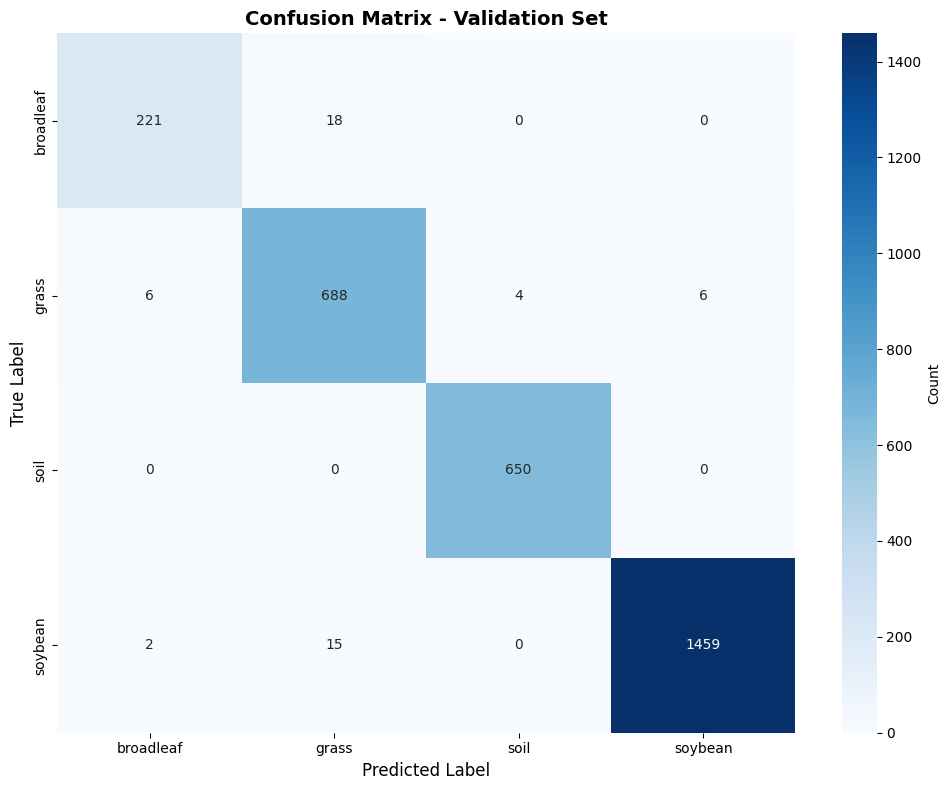

Confusion matrix saved as 'confusion_matrix_LatentClassifier_D_SnE.png'

Classification Report
              precision    recall  f1-score   support

   broadleaf     0.9651    0.9247    0.9444       239
       grass     0.9542    0.9773    0.9656       704
        soil     0.9939    1.0000    0.9969       650
     soybean     0.9959    0.9885    0.9922      1476

    accuracy                         0.9834      3069
   macro avg     0.9773    0.9726    0.9748      3069
weighted avg     0.9835    0.9834    0.9834      3069



In [52]:

# * Confusion Matrix

# * Get final validation predictions
# ✅ Load the checkpoint and extract model_state_dict
checkpoint = torch.load(best_classifier_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])  # Extract the actual model weights
model.eval()  # Set to evaluation mode

_, _, _, _, _, val_labels, val_preds, _ = validate_epoch(model, val_loader, criterion, device)

# * Compute confusion matrix
cm = confusion_matrix(val_labels, val_preds)

# * Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_folders, 
            yticklabels=class_folders,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Validation Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f'confusion_matrix_{model_name}.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Confusion matrix saved as 'confusion_matrix_{model_name}.png'")

# * Print classification report
print("\n" + "="*60)
print("Classification Report")
print("="*60)
print(classification_report(val_labels, val_preds, target_names=class_folders, digits=4))

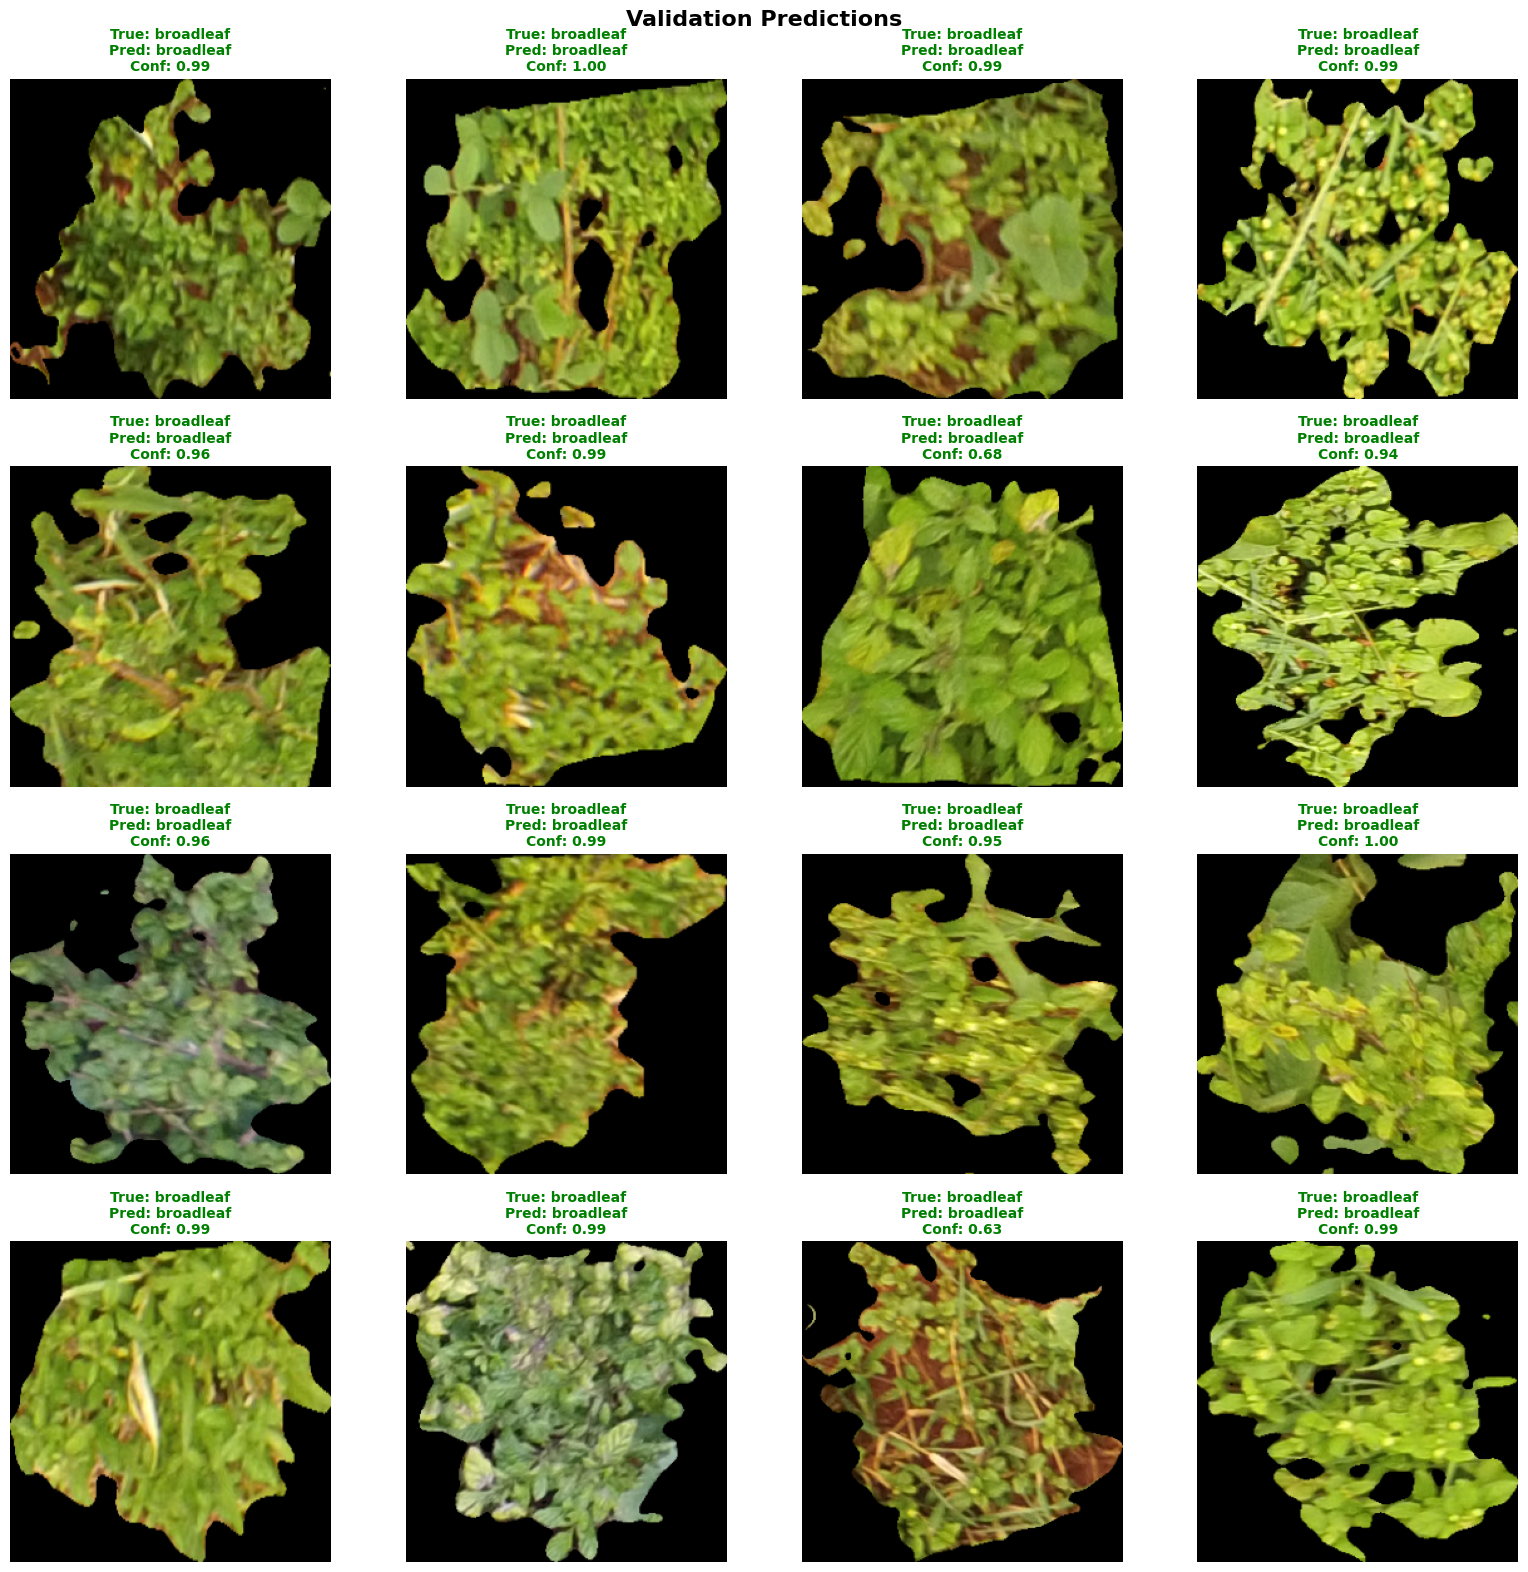

Validation predictions visualization saved as 'validation_predictions_LatentClassifier_D_SnE.png'


In [54]:

# * Visualize Validation Predictions
def visualize_predictions(model, val_loader, device, num_samples=16):
    model.eval()
    
    # * Get a batch of images
    images_list = []
    labels_list = []
    preds_list = []
    probs_list = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            images_list.extend(images.cpu())
            labels_list.extend(labels.cpu().numpy())
            preds_list.extend(preds.cpu().numpy())
            probs_list.extend(probs.cpu().numpy())
            
            if len(images_list) >= num_samples:
                break
    
    # * Plot
    rows = 4
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(16, 16))
    fig.suptitle('Validation Predictions', fontsize=16, fontweight='bold')
    
    for idx in range(min(num_samples, len(images_list))):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col]
        
        # * Get image and convert to numpy
        img = images_list[idx].permute(1, 2, 0).numpy()
        
        # * Denormalize if needed (already in [0,1])
        img = np.clip(img, 0, 1)
        
        true_label = idx_to_class[labels_list[idx]]
        pred_label = idx_to_class[preds_list[idx]]
        confidence = probs_list[idx][preds_list[idx]]
        
        # * Display image
        ax.imshow(img)
        ax.axis('off')
        
        # * Color: green if correct, red if wrong
        color = 'green' if labels_list[idx] == preds_list[idx] else 'red'
        
        title = f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}"
        ax.set_title(title, fontsize=10, color=color, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'validation_predictions_{model_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Validation predictions visualization saved as 'validation_predictions_{model_name}.png'")

# ✅ Load best CLASSIFIER model (not VQVAE model!)
checkpoint = torch.load(best_classifier_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

visualize_predictions(model, val_loader, device, num_samples=16)

In [55]:

# * Save Training Summary
summary_df = pd.DataFrame({
    'Epoch': range(1, EPOCHS + 1),
    'Train_Loss': history['train_loss'],
    'Train_Acc': history['train_acc'],
    'Train_Precision': history['train_precision'],
    'Train_Recall': history['train_recall'],
    'Train_F1': history['train_f1'],
    'Val_Loss': history['val_loss'],
    'Val_Acc': history['val_acc'],
    'Val_Precision': history['val_precision'],
    'Val_Recall': history['val_recall'],
    'Val_F1': history['val_f1']
})

summary_df.to_csv(f'training_summary_{model_name}.csv', index=False)
print(f"Training summary saved as 'training_summary_{model_name}.csv'")
print("\n" + "="*60)
print("Training Summary:")
print("="*60)
print(summary_df.to_string(index=False))

Training summary saved as 'training_summary_LatentClassifier_D_SnE.csv'

Training Summary:
 Epoch  Train_Loss  Train_Acc  Train_Precision  Train_Recall  Train_F1  Val_Loss  Val_Acc  Val_Precision  Val_Recall   Val_F1
     1    0.623432   0.771990         0.671835      0.597152  0.581529  0.350366 0.857934       0.643302    0.690326 0.665309
     2    0.335133   0.868427         0.769285      0.708030  0.686161  0.387468 0.850114       0.849482    0.717091 0.746970
     3    0.261778   0.899242         0.843484      0.768218  0.774984  0.182523 0.931900       0.907707    0.837419 0.855496
     4    0.209787   0.919296         0.872441      0.828745  0.842825  0.199039 0.918540       0.879697    0.888229 0.873880
     5    0.171466   0.936333         0.902604      0.872782  0.884983  0.129830 0.954057       0.919586    0.929596 0.922844
     6    0.140553   0.949539         0.920817      0.906071  0.912930  0.289788 0.902574       0.908684    0.762913 0.751423
     7    0.124169   0.9554

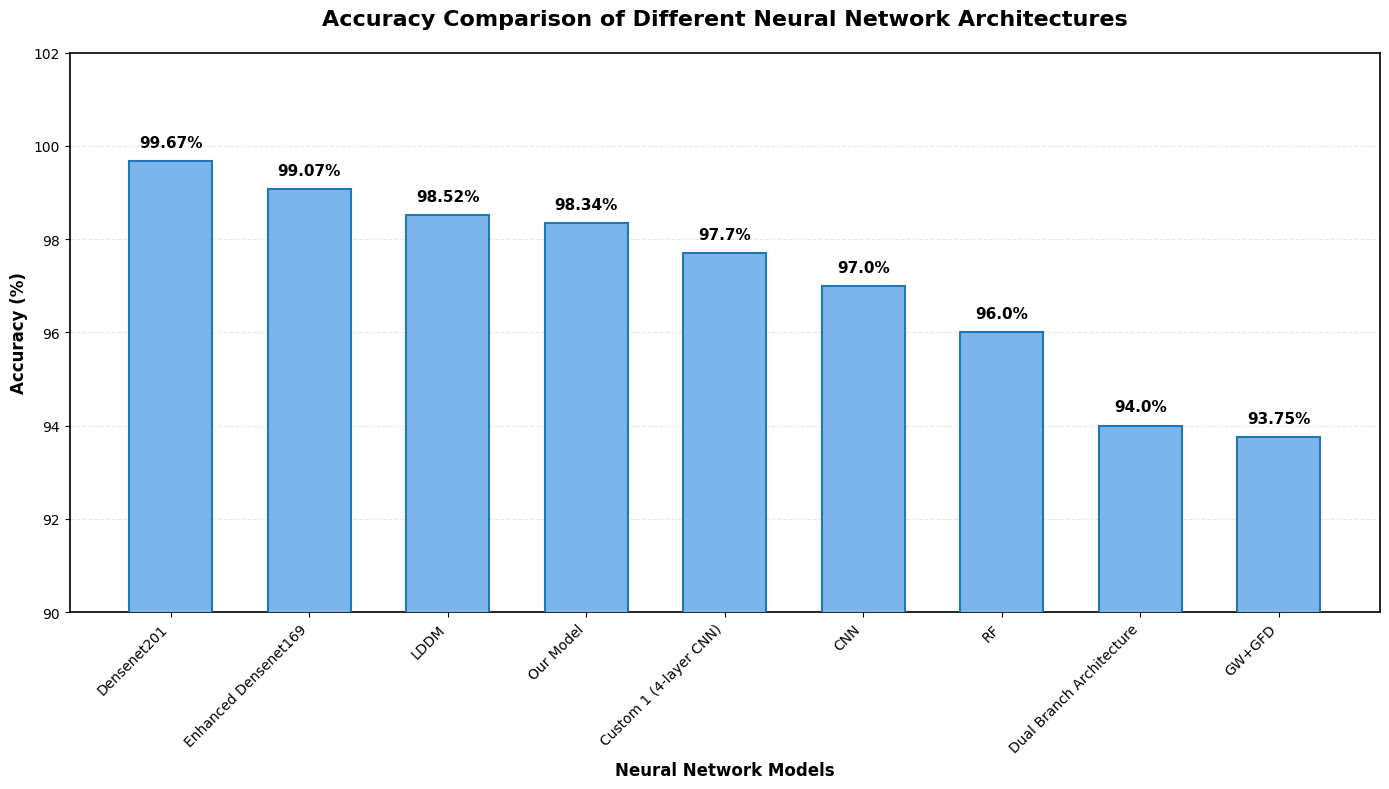

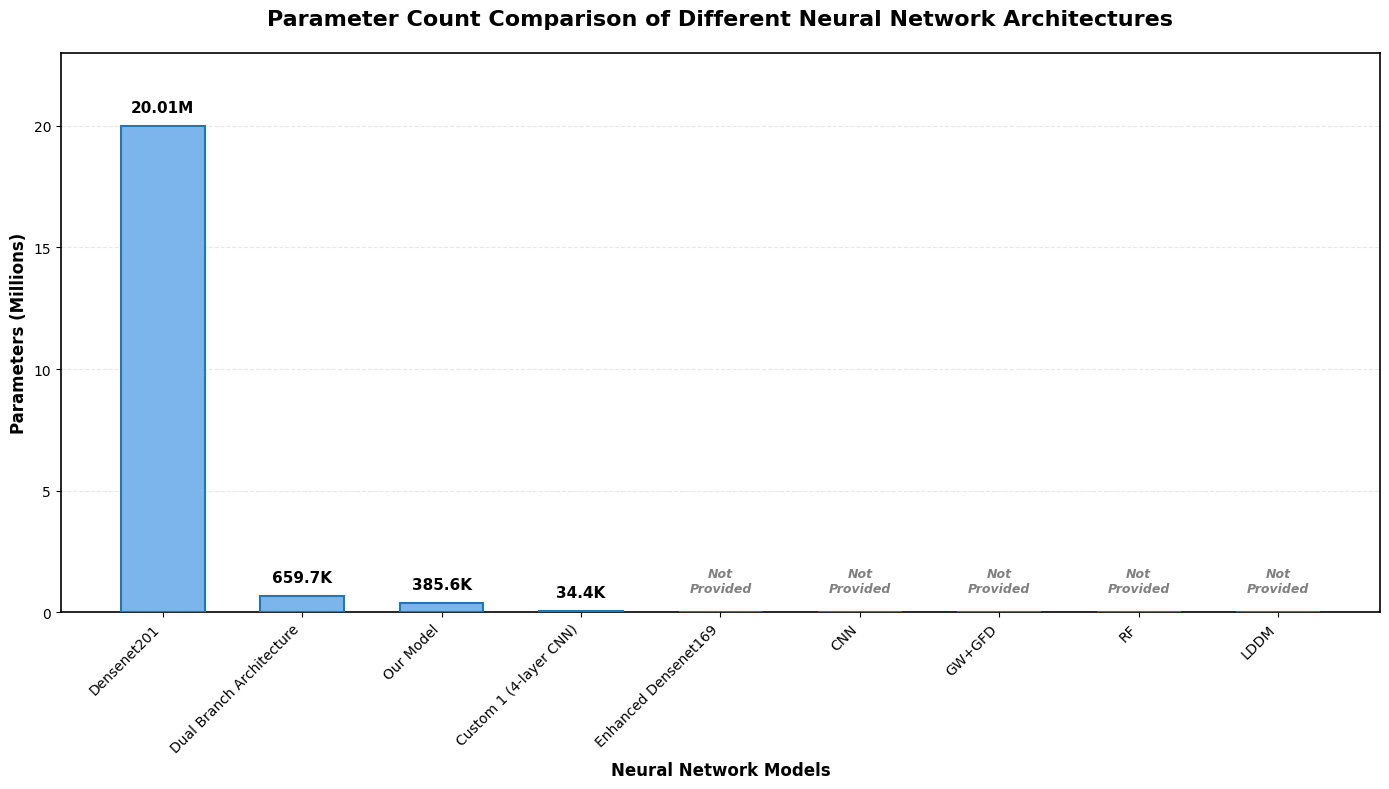

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re

# 1. Data Setup
data = [
    {"name": r"Densenet201 \cite{babu2024}", "accuracy": 99.67, "params": "20.01 M"},
    {"name": r"Enhanced Densenet169 \cite{ajay2025}", "accuracy": 99.07, "params": "-"},
    {"name": r"Custom 1 (4-layer CNN) \cite{razfar2022}", "accuracy": 97.7, "params": "34,368"},
    {"name": r"Dual Branch Architecture \cite{tripathi2025}", "accuracy": 94.00, "params": "659,724"},
    {"name": r"CNN \cite{vad2020}", "accuracy": 97.00, "params": "--"},
    {"name": r"GW+GFD \cite{Ishak2008Weed}", "accuracy": 93.75, "params": "--"},
    {"name": r"RF \cite{IslamEarlyWeedDetection}", "accuracy": 96.00, "params": "--"},
    {"name": r"LDDM \cite{ambuj2025}", "accuracy": 98.52, "params": "--"},
    {"name": "Our Model", "accuracy": 98.34, "params": "385,604"}
]

# 2. Helper Functions
def clean_name(name):
    return re.sub(r'\s*\\cite\{.*?\}', '', name).strip()

def parse_params(param_str):
    param_str = str(param_str).strip()
    if param_str in ["-", "--"]:
        return np.nan
    if "M" in param_str:
        return float(param_str.replace("M", "").strip()) * 1_000_000
    return float(param_str.replace(",", ""))

def format_param_label(val):
    if pd.isna(val):
        return "Not\nProvided"
    if val >= 1_000_000:
        return f"{val/1_000_000:.2f}M"
    if val >= 1_000:
        return f"{val/1_000:.1f}K"
    return str(int(val))

# Prepare DataFrame
df = pd.DataFrame(data)
df['cleaned_name'] = df['name'].apply(clean_name)
df['cleaned_params'] = df['params'].apply(parse_params)

# 3. Plotting Function with Scaled Y-Axis
def create_styled_chart(dataframe, value_col, title, ylabel, is_parameter_chart=False):
    # Sorting
    if is_parameter_chart:
        dataframe['sort_val'] = dataframe[value_col].fillna(-1) 
        df_sorted = dataframe.sort_values(by='sort_val', ascending=False)
    else:
        df_sorted = dataframe.sort_values(by=value_col, ascending=False)

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=0, color='lightgray')

    bar_colors = '#7cb5ec' 
    edge_colors = '#1f77b4'
    
    # Get raw values (filling NaN with 0 for plotting)
    raw_values = df_sorted[value_col].fillna(0)
    
    # SCALE THE VALUES if it's the parameter chart
    if is_parameter_chart:
        plot_values = raw_values / 1_000_000
    else:
        plot_values = raw_values

    bars = ax.bar(df_sorted['cleaned_name'], plot_values, 
                  color=bar_colors, edgecolor=edge_colors, 
                  linewidth=1.5, zorder=3, width=0.6)

    # Dynamic Y-limit adjustment
    max_val = plot_values.max()
    if is_parameter_chart:
        ax.set_ylim(0, max_val * 1.15)
    else:
        ax.set_ylim(90, 102) 

    # --- GAP FIX LOGIC ---
    # Calculate the total range of the Y-axis
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Add Labels
    for bar, original_val in zip(bars, df_sorted[value_col]):
        height = bar.get_height()
        x_pos = bar.get_x() + bar.get_width() / 2
        
        if pd.isna(original_val):
            # FIX: Use 3% of the y-range as the vertical offset instead of fixed 0.1
            gap_offset = y_min + (y_range * 0.03) 
            
            ax.text(x_pos, gap_offset, "Not\nProvided", 
                    ha='center', va='bottom', 
                    color='gray', style='italic', fontweight='bold', fontsize=9)
        else:
            if is_parameter_chart:
                label_text = format_param_label(original_val)
            else:
                label_text = f"{original_val}%"
            
            y_offset = height + (y_range * 0.02)
            
            ax.text(x_pos, y_offset, label_text, 
                    ha='center', va='bottom', 
                    color='black', fontweight='bold', fontsize=11)

    ax.set_title(title, fontweight='bold', fontsize=16, pad=20)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    ax.set_xlabel("Neural Network Models", fontweight='bold', fontsize=12)

    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)
    
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)
        spine.set_color('black')

    plt.tight_layout()
    plt.savefig(f"{'params' if is_parameter_chart else 'accuracy'}_chart_gap_fixed.png")
    plt.show()

# Generate charts
create_styled_chart(df, 'accuracy', 
                   'Accuracy Comparison of Different Neural Network Architectures', 
                   'Accuracy (%)', 
                   is_parameter_chart=False)

create_styled_chart(df, 'cleaned_params', 
                   'Parameter Count Comparison of Different Neural Network Architectures', 
                   'Parameters (Millions)', 
                   is_parameter_chart=True)